In [1]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

2026-04-12 14:06:55.603806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776002815.987541      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776002816.102473      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [3]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [4]:
tr_df = train_df('/kaggle/input/brain-tumor-mri-dataset/Training')

In [5]:
tr_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5595,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5596,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5597,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5598,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [6]:
ts_df = test_df('/kaggle/input/brain-tumor-mri-dataset/Testing')

In [7]:
ts_df 

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1595,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1596,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1597,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1598,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


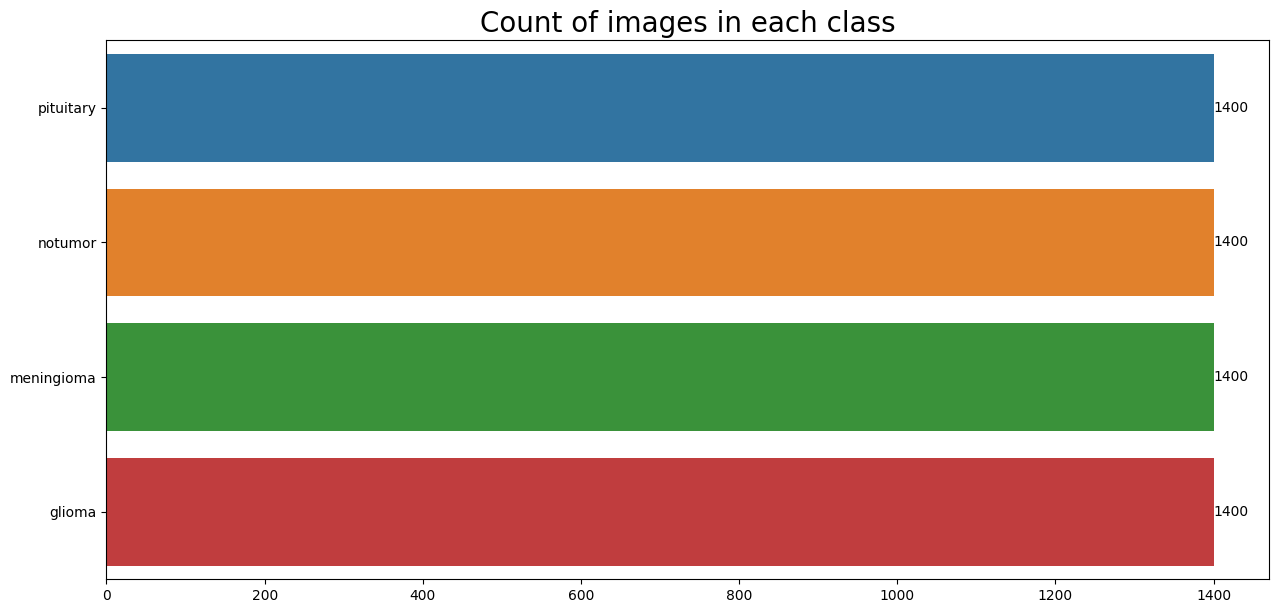

In [8]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

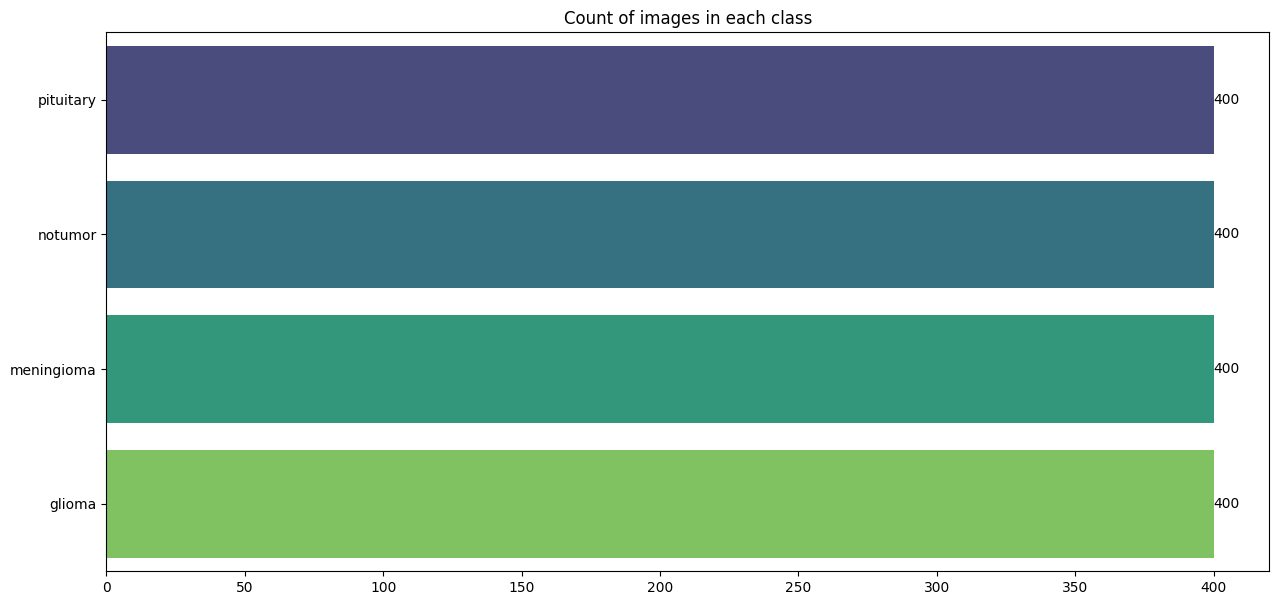

In [9]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

In [10]:
import os

def count_images_in_directory(base_path):
    """
    Counts total number of images and per-class counts inside each subfolder.
    """
    total_images = 0
    class_counts = {}

    for class_name in os.listdir(base_path):
        class_folder = os.path.join(base_path, class_name)
        if os.path.isdir(class_folder):
            count = len([
                img for img in os.listdir(class_folder)
                if img.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))
            ])
            class_counts[class_name] = count
            total_images += count

    return total_images, class_counts


# Paths (update these if needed)
train_path = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_path = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# Count training and testing images
train_total, train_classes = count_images_in_directory(train_path)
test_total, test_classes = count_images_in_directory(test_path)

print("=== Training Set ===")
for cls, count in train_classes.items():
    print(f"{cls:15}: {count} images")
print(f"Total Training Images: {train_total}\n")

print("=== Testing Set ===")
for cls, count in test_classes.items():
    print(f"{cls:15}: {count} images")
print(f"Total Testing Images: {test_total}")


=== Training Set ===
pituitary      : 1400 images
notumor        : 1400 images
meningioma     : 1400 images
glioma         : 1400 images
Total Training Images: 5600

=== Testing Set ===
pituitary      : 400 images
notumor        : 400 images
meningioma     : 400 images
glioma         : 400 images
Total Testing Images: 1600


In [11]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [12]:
valid_df

,Class Path,Class
198,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
857,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
1098,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
1119,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
508,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
...,...,...
1281,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
172,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
792,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
933,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma


In [13]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


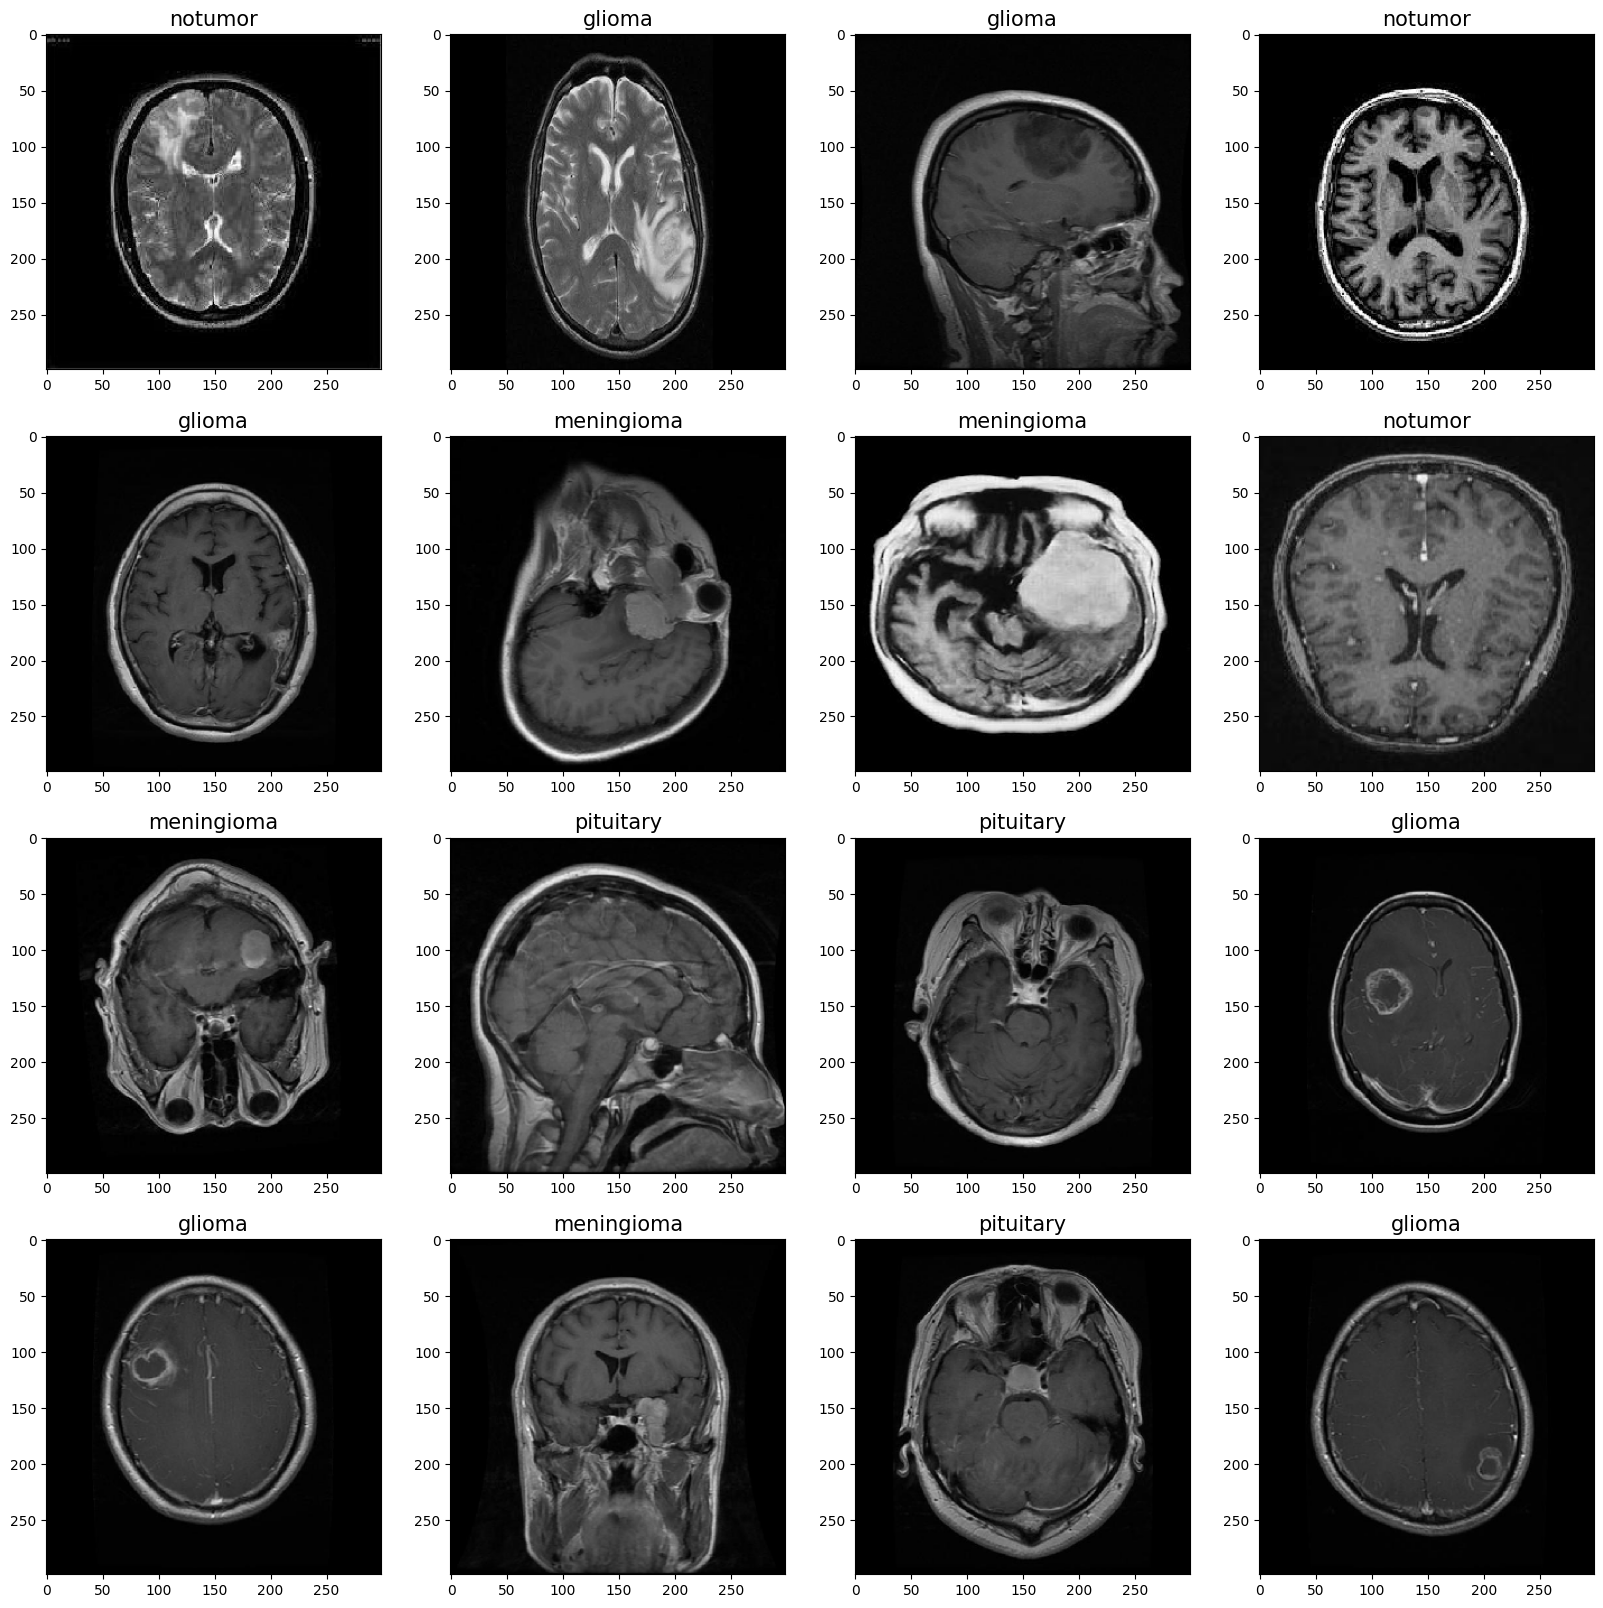

In [14]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

In [15]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False
    
model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

I0000 00:00:1776002868.157682      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776002868.160672      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ (None, 2048)                │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

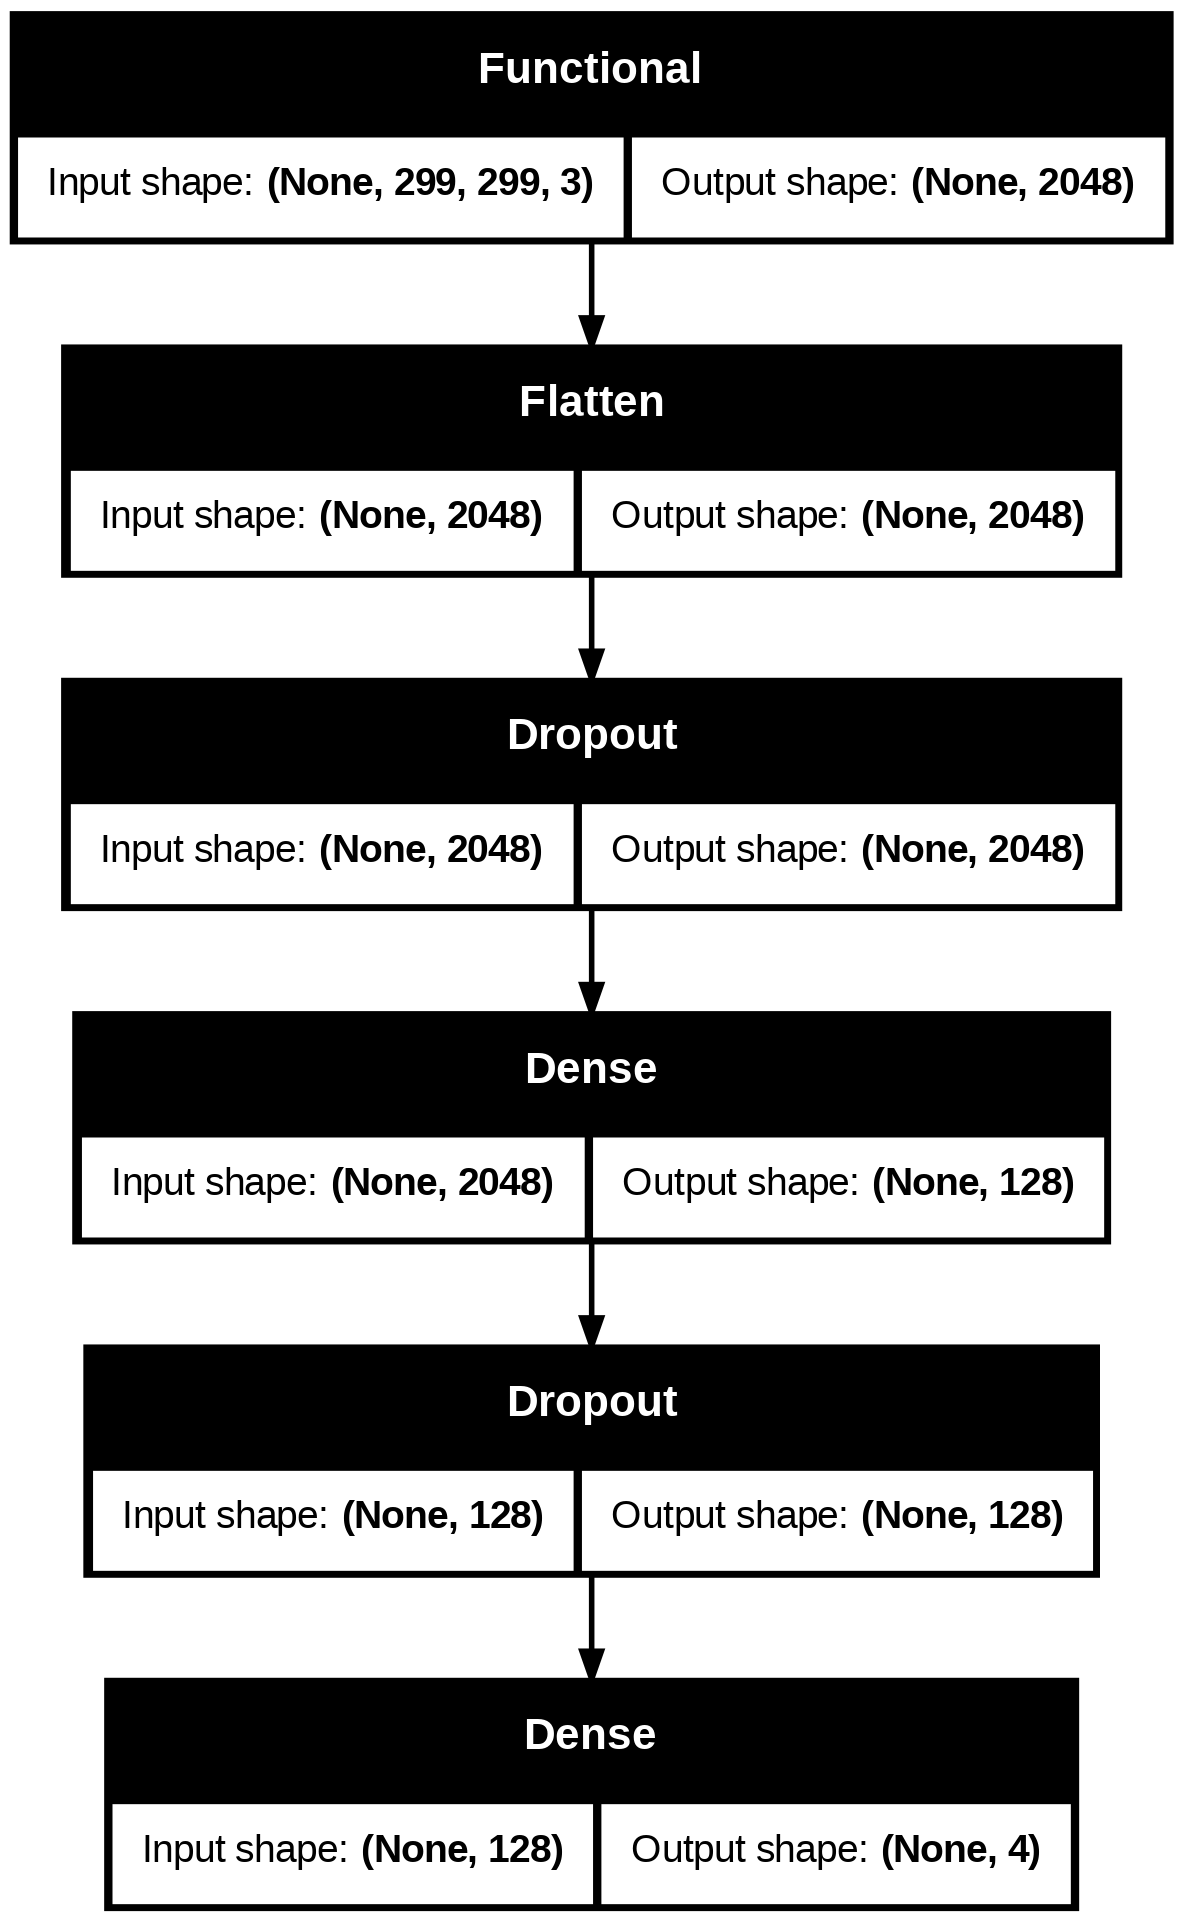

In [16]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [18]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# ── 1. Mixed Precision (faster GPU computation) ──────────────────────────────
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# ── 2. Freeze base model layers (only train your custom head) ─────────────────
for layer in base_model.layers:
    layer.trainable = False

# ── 3. Recompile after freezing ───────────────────────────────────────────────
model.compile(Adamax(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(), Recall()])

# ── 4. Callbacks: EarlyStopping + ReduceLROnPlateau ──────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

# ── 5. Train ──────────────────────────────────────────────────────────────────
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 callbacks=callbacks,
                 shuffle=False)


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 403ms/step - accuracy: 0.8516 - loss: 0.4240 - precision_1: 0.8642 - recall_1: 0.8406 - val_accuracy: 0.8537 - val_loss: 0.4888 - val_precision_1: 0.8634 - val_recall_1: 0.8375 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 310ms/step - accuracy: 0.9045 - loss: 0.2718 - precision_1: 0.9113 - recall_1: 0.8937 - val_accuracy: 0.8500 - val_loss: 0.4667 - val_precision_1: 0.8621 - val_recall_1: 0.8363 - learning_rate: 0.0010
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 305ms/step - accuracy: 0.9058 - loss: 0.2615 - precision_1: 0.9141 - recall_1: 0.8969 - val_accuracy: 0.8537 - val_loss: 0.5146 - val_precision_1: 0.8562 - val_recall_1: 0.8413 - learning_rate: 0.0010
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 307ms/step - accuracy: 0.9164 - loss: 0.2324 - precision_1: 0.9255 - recall_1: 0.9082 - val_accuracy: 0.8612 - val_loss: 0.4564 - val_precision_1: 0.8682 - val_recall_1: 0.8562 - learning_rate: 0.0010
Epoch 5/10
175/175 ━

In [21]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision_1', 'recall_1', 'val_accuracy', 'val_loss', 'val_precision_1', 'val_recall_1', 'learning_rate'])

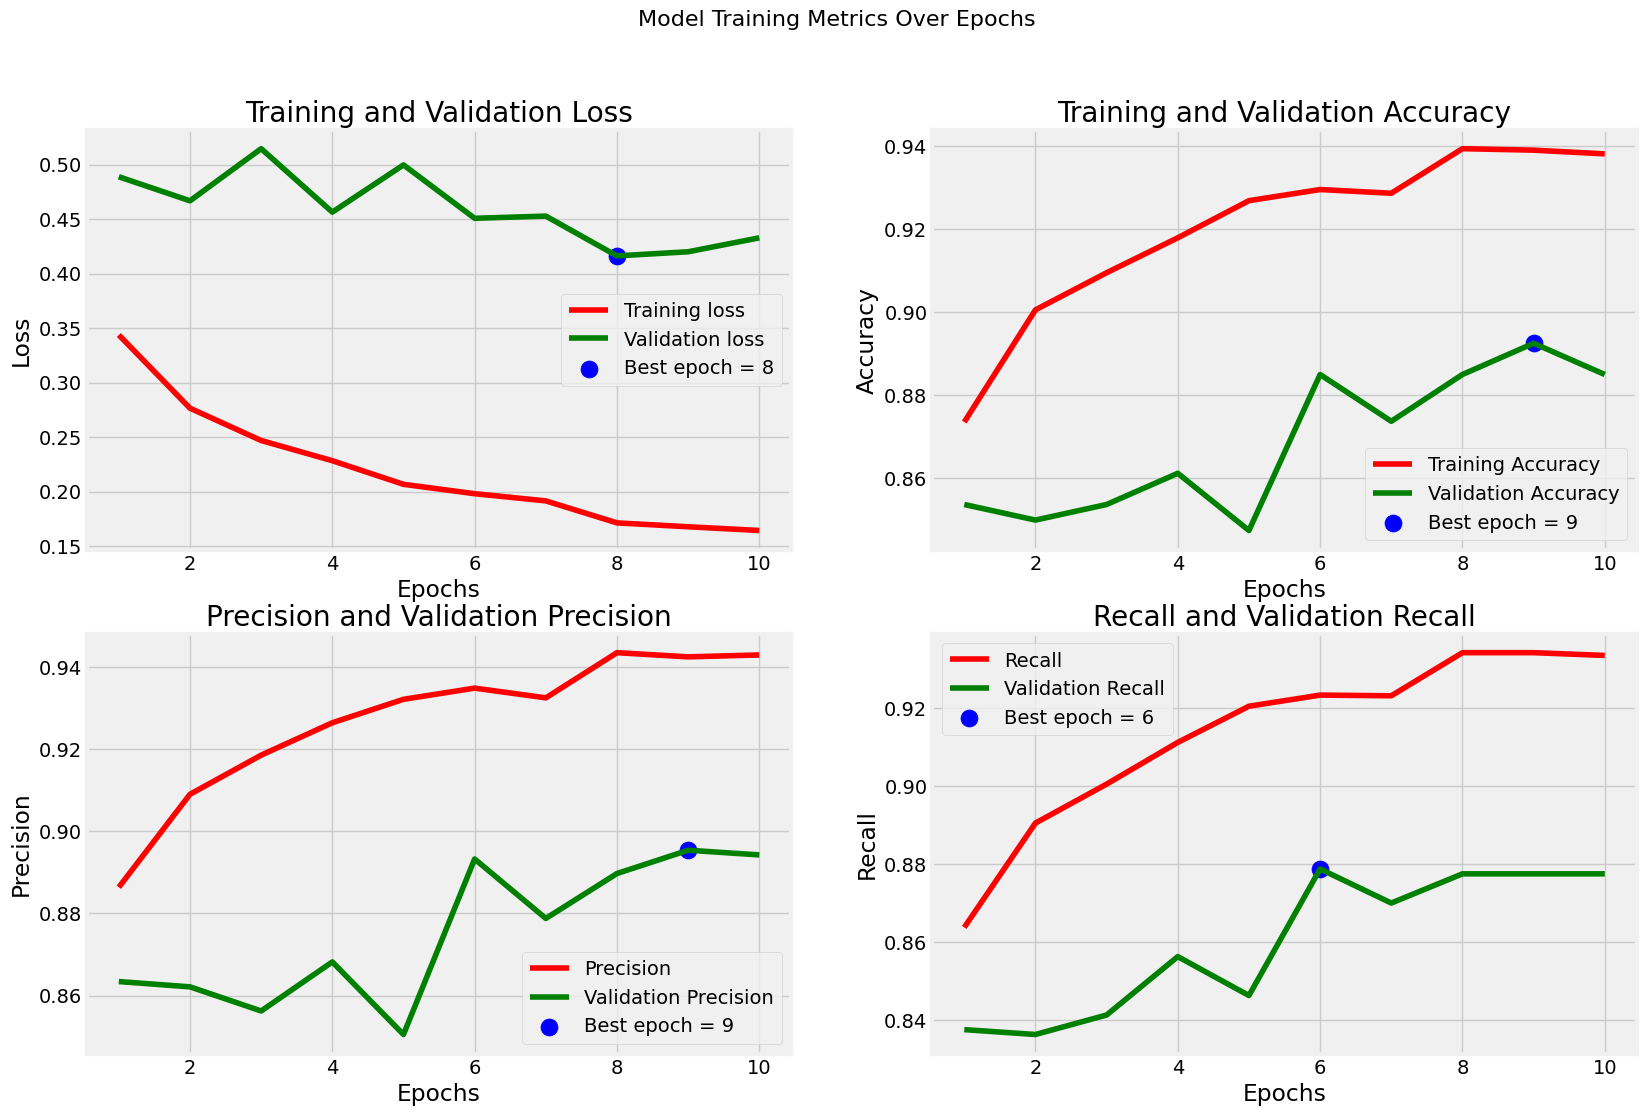

In [25]:
tr_acc    = hist.history['accuracy']
tr_loss   = hist.history['loss']
tr_per    = hist.history['precision_1']       # ← fixed
tr_recall = hist.history['recall_1']          # ← fixed
val_acc    = hist.history['val_accuracy']
val_loss   = hist.history['val_loss']
val_per    = hist.history['val_precision_1']  # ← fixed
val_recall = hist.history['val_recall_1']     # ← fixed

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'

plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()


In [26]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 273ms/step - accuracy: 0.9578 - loss: 0.1263 - precision_1: 0.9612 - recall_1: 0.9550
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.8860 - loss: 0.3957 - precision_1: 0.8904 - recall_1: 0.8734
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.8696 - loss: 0.4622 - precision_1: 0.8778 - recall_1: 0.8640
Train Loss: 0.1287
Train Accuracy: 95.46%
--------------------
Validation Loss: 0.4073
Validation Accuracy: 88.50%
--------------------
Test Loss: 0.4658
Test Accuracy: 87.75%


In [27]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step


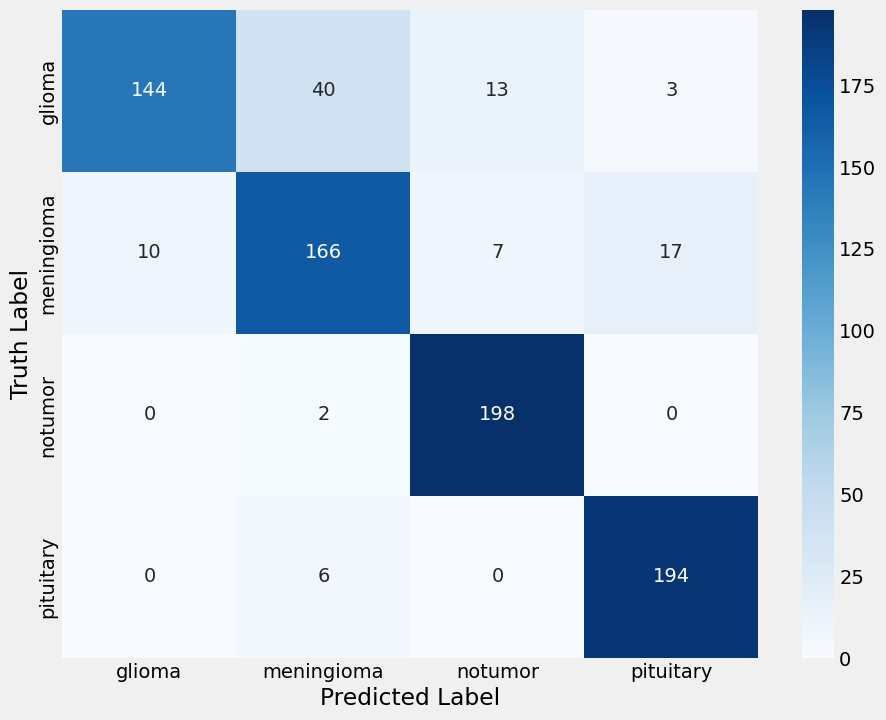

In [28]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [29]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.94      0.72      0.81       200
           1       0.78      0.83      0.80       200
           2       0.91      0.99      0.95       200
           3       0.91      0.97      0.94       200

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800



In [33]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image

    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))

    img = Image.open(img_path).convert('RGB')   # ← FIXED: forces 3 channels
    resized_img = img.resize((299, 299))
    img = np.asarray(resized_img)               # shape will now be (299, 299, 3)
    img = np.expand_dims(img, axis=0)           # shape → (1, 299, 299, 3)
    img = img / 255.0

    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label

    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt='%.2f')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


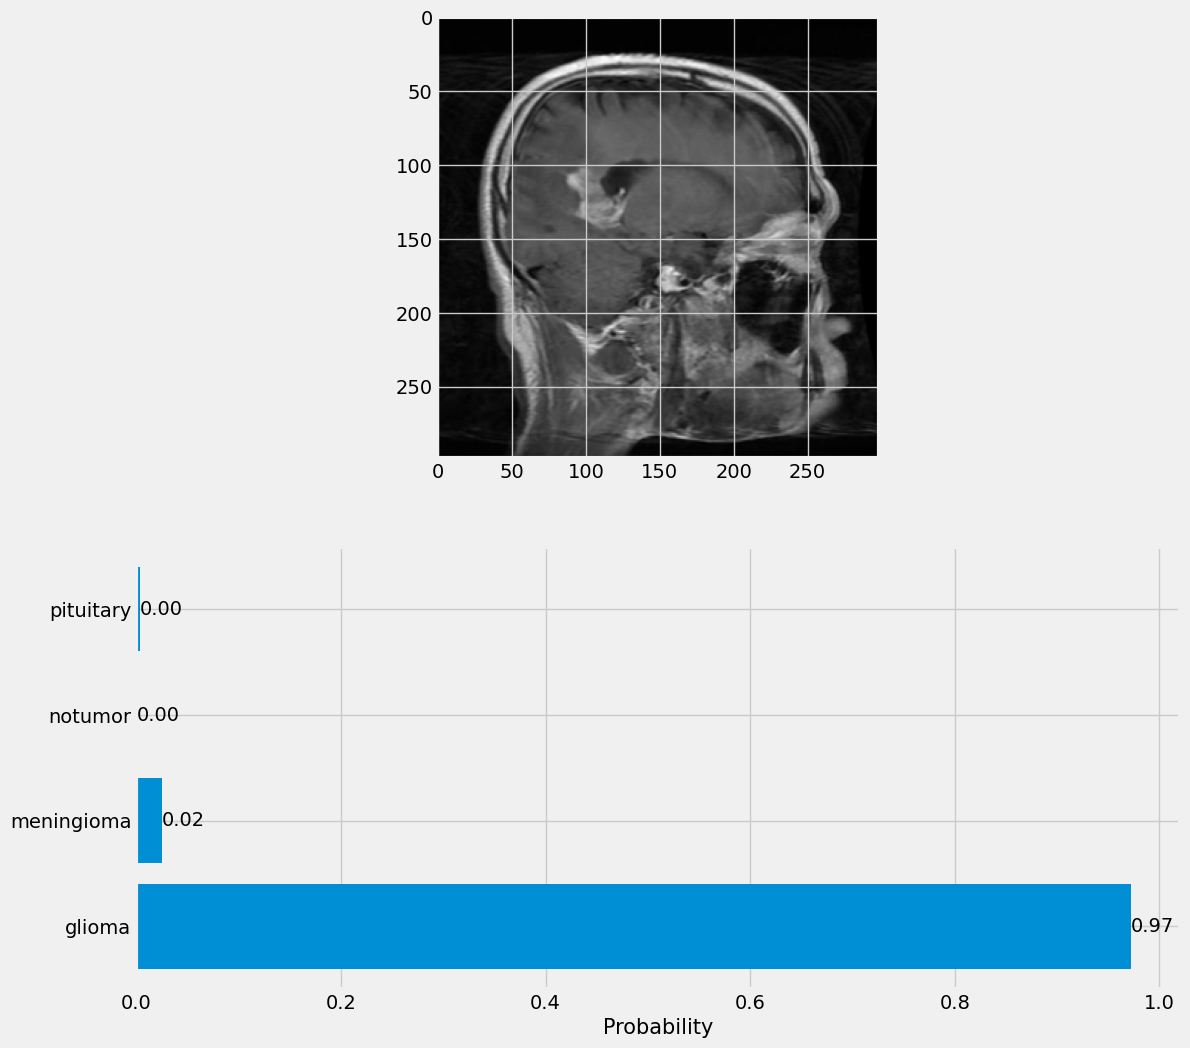

In [34]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_101.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


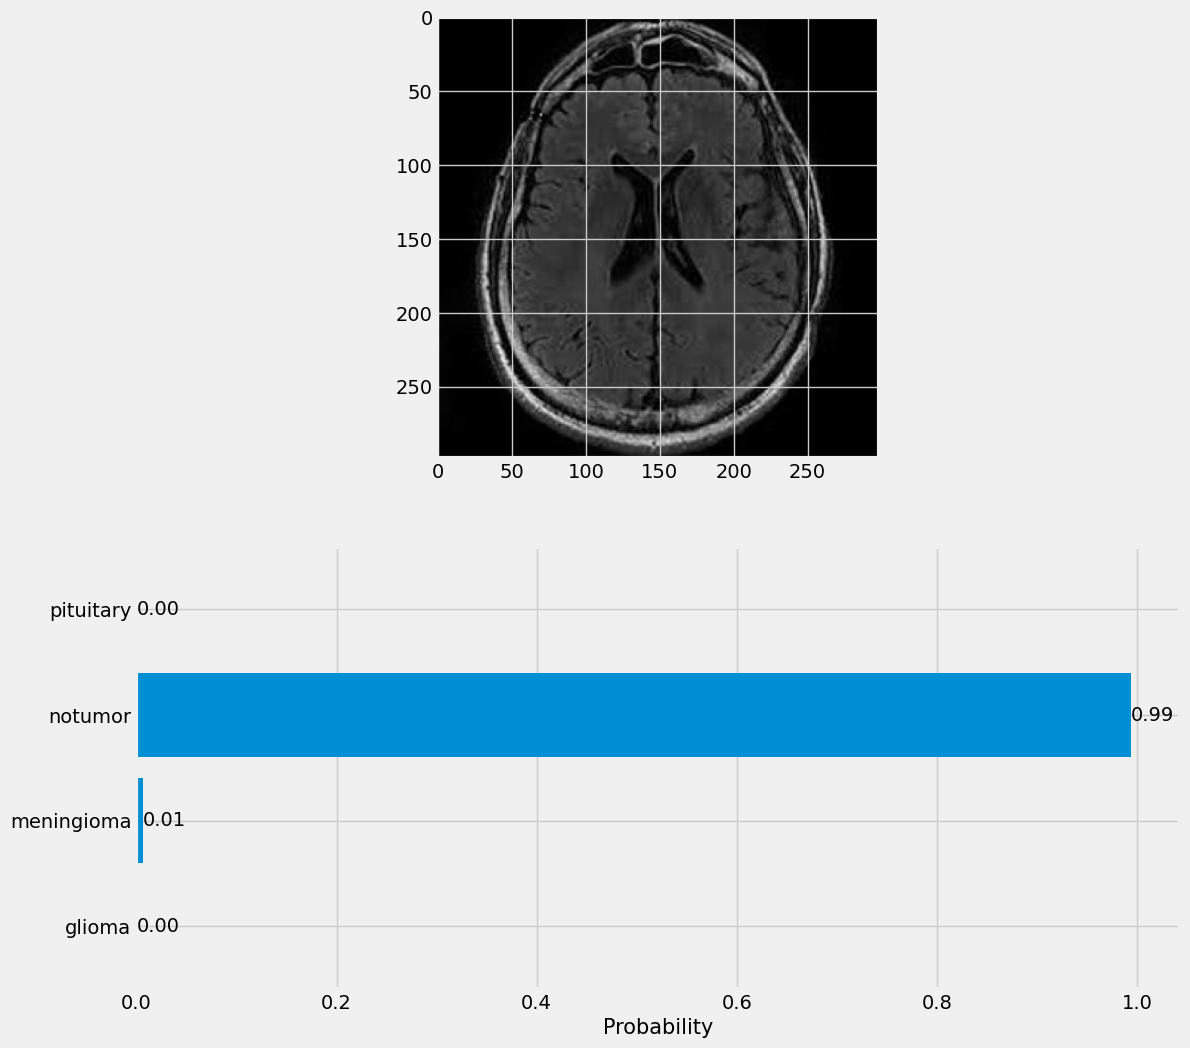

In [36]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-no_101.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


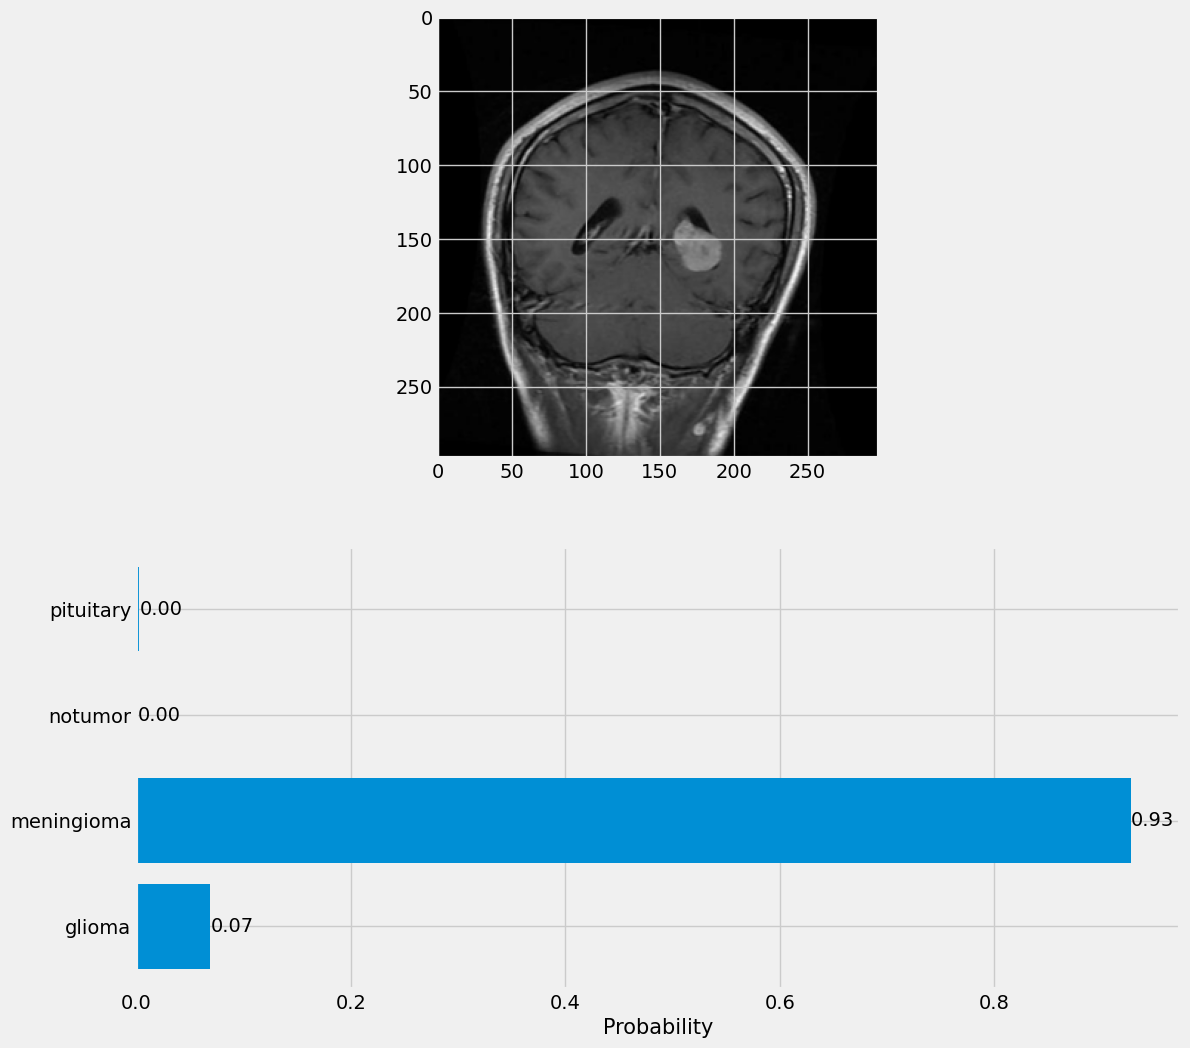

In [37]:
predict('/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_11.jpg')

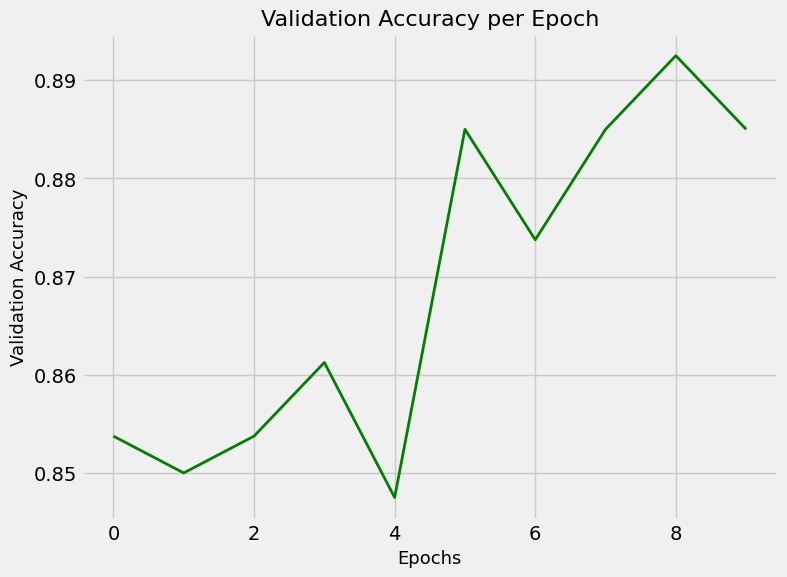

In [38]:
import matplotlib.pyplot as plt

# Plot Validation Accuracy
plt.figure(figsize=(8,6))
plt.plot(hist.history['val_accuracy'], color='green', linewidth=2)
plt.title('Validation Accuracy per Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.grid(True)
plt.show()


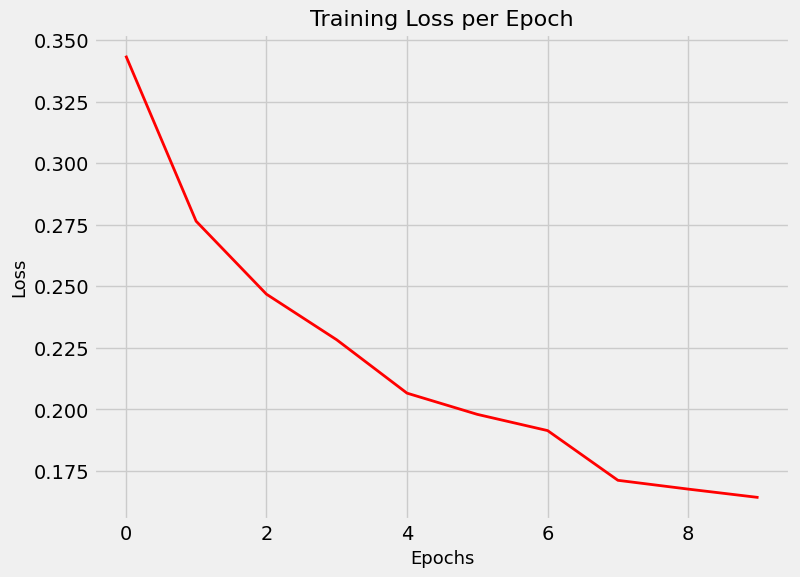

In [39]:
import matplotlib.pyplot as plt

# Plot Training Loss
plt.figure(figsize=(8,6))
plt.plot(hist.history['loss'], color='red', linewidth=2)
plt.title('Training Loss per Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.grid(True)
plt.show()


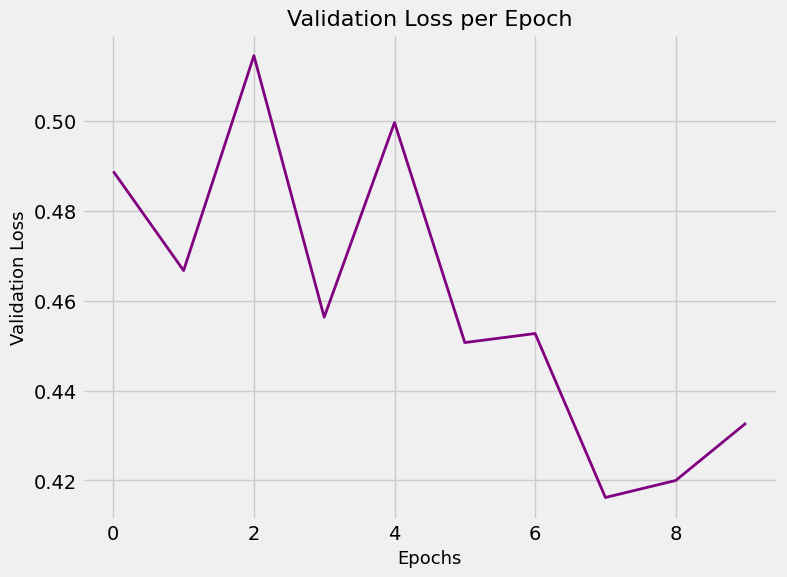

In [40]:
import matplotlib.pyplot as plt

# Plot Validation Loss
plt.figure(figsize=(8,6))
plt.plot(hist.history['val_loss'], color='purple', linewidth=2)
plt.title('Validation Loss per Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Validation Loss', fontsize=13)
plt.grid(True)
plt.show()


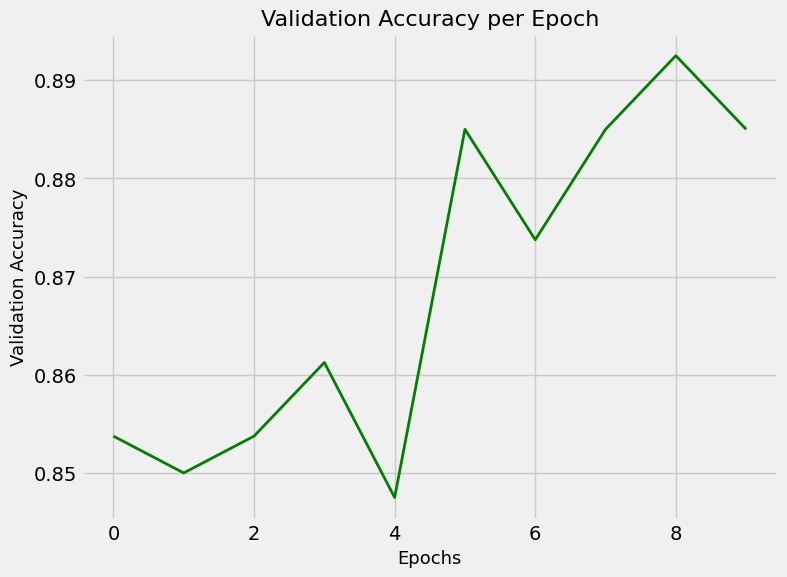

In [41]:
import matplotlib.pyplot as plt

# Plot Validation Accuracy
plt.figure(figsize=(8,6))
plt.plot(hist.history['val_accuracy'], color='green', linewidth=2)
plt.title('Validation Accuracy per Epoch', fontsize=16)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.grid(True)
plt.show()
